In [25]:
%matplotlib inline
import os
import xarray as xr
import numpy as np

In [2]:
NODES_PER_TILE=1506

In [3]:
loc="/datasets/work/oa-ppbcha/work/PPBCHA/schism_output/baseline"

In [4]:
# get variables to lookup lat/lon
f1 = xr.open_dataset(os.path.join(loc, "1981/schout_1981_01.nc"))

In [5]:
#dir(f1)

In [6]:
lon=f1.SCHISM_hgrid_node_x.values
lat=f1.SCHISM_hgrid_node_y.values
f1.close()

In [7]:
lon

array([ 145.46470642,  145.46499634,  145.46440125, ...,  144.9046936 ,
        144.90449524,  144.90460205], dtype=float32)

In [8]:
lat0=-38.0
lon0=144.9

In [9]:
# lookup tile number and position within each tile.
def tile_lookup(x,y,lon,lat):
    l1norm = abs(y-lat)+abs(x-lon)
    global_node = np.argmin(l1norm)
    tile_num = (global_node-1)//NODES_PER_TILE
    tile_node = (global_node -1) % NODES_PER_TILE + 1
    return tile_num, tile_node
    

In [10]:
tile_num, tile_node = tile_lookup(lon0, lat0, lon, lat)

In [11]:
tile_num, tile_node

(96, 555)

In [12]:
# Open tile to get time series
f2 = xr.open_dataset(os.path.join(loc,"timeseries/chunked/t{}.nc".format(tile_num)))

In [13]:
# Just getting one variable
var1=f2.WWM_1

In [14]:
var1

<xarray.DataArray 'WWM_1' (time: 306065, nSCHISM_hgrid_node: 1506)>
[460933890 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1980-01-02T01:00:00 ... 2015-01-01
Dimensions without coordinates: nSCHISM_hgrid_node
Attributes:
    mesh:                    SCHISM_hgrid
    data_horizontal_center:  node
    data_vertical_center:    full
    i23d:                    1
    ivs:                     1

In [15]:
# select by node number
data=var1.isel(nSCHISM_hgrid_node=tile_node)

In [16]:
# np.array you can do things with
data.values

array([ 0.002391  ,  0.20590684,  0.32282871, ...,  0.0897477 ,
        0.08253953,  0.07854772], dtype=float32)

In [17]:
# Let's say we are looking up several lat/lon (e.g. in a loop).
# Might want to check whether we need to open a new file or not.
lat0=-38.1
lon0=144.8

In [18]:
new_tile_num, tile_node = tile_lookup(lon0, lat0, lon, lat)

In [19]:
new_tile_num, tile_node

(90, 692)

In [20]:
if new_tile_num != tile_num:
    f2.close()
    f2 = xr.open_dataset(os.path.join(loc,"timeseries/chunked/t{}.nc".format(new_tile_num)))

In [21]:
# get the next data
var1=f2.WWM_1

In [22]:
# extract the required node
data=var1.isel(nSCHISM_hgrid_node=tile_node)

In [45]:
# reduce the data down to daily
daily_data = data.resample(time='1D').mean()

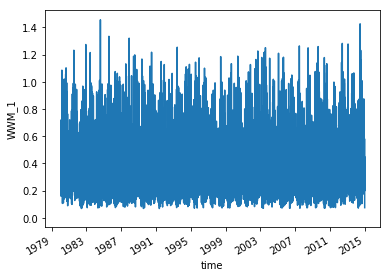

In [46]:
daily_data.plot()